# Milestone 1 — Reflection Questions

Four quantitative exercises that probe the limits of the search space,
the geometry of random genomes, and the practical cost of simulation.


In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage
from IPython.display import Image, display

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.environ.setdefault("VOXCRAFT_BIN", os.path.join(PROJECT_ROOT, "voxelyze"))

from src.milestone1.genome import random_genome, largest_connected_component, voxel_counts
from src.milestone1.fitness import evaluate_genome
from src.milestone1.visualize import render_genome


---
## Q1 · Size of the Search Space

With an **8×8×8 grid** and **4 material types** per voxel (empty, passive, active+, active−),
each genome is one point in a discrete space of size:

$$|\mathcal{S}| = 4^{8 \times 8 \times 8} = 4^{512}$$

How does this compare to the number of atoms in the observable universe (~10⁸⁰)?


In [2]:
import math

GRID = 8 * 8 * 8          # 512 voxels
MATERIALS = 4

# Exact exponent: 4^512 = 10^(512 * log10(4))
log10_space = GRID * math.log10(MATERIALS)
log10_universe = 80        # atoms in observable universe

print("=" * 55)
print(f"Grid voxels             : {GRID}")
print(f"Material types          : {MATERIALS}")
print(f"Search space size       : 4^{GRID} ≈ 10^{log10_space:.1f}")
print(f"Atoms in universe       : ≈ 10^{log10_universe}")
print(f"Ratio (space / atoms)   : ≈ 10^{log10_space - log10_universe:.1f}")
print("=" * 55)

# How many genomes could we evaluate?
ns_per_year = 3.154e16          # nanoseconds in a year
age_of_universe_yr = 1.38e10    # years
total_ns = ns_per_year * age_of_universe_yr
log10_evaluated = math.log10(total_ns)
fraction_explored = log10_evaluated - log10_space

print(f"\n1 eval/ns since Big Bang → ≈ 10^{log10_evaluated:.1f} evaluations")
print(f"Fraction explored       : 10^{fraction_explored:.0f}  (effectively zero)")
print()
print("Implication: exhaustive search is physically impossible.")
print("Evolutionary search is not optional — it is the only viable strategy.")


Grid voxels             : 512
Material types          : 4
Search space size       : 4^512 ≈ 10^308.3
Atoms in universe       : ≈ 10^80
Ratio (space / atoms)   : ≈ 10^228.3

1 eval/ns since Big Bang → ≈ 10^26.6 evaluations
Fraction explored       : 10^-282  (effectively zero)

Implication: exhaustive search is physically impossible.
Evolutionary search is not optional — it is the only viable strategy.


---
## Q2 · Distribution of Connected Components

For **500 random genomes** (seed 42), count the number of 6-connected components
in each. Then ask:

- What does the distribution look like?
- What fraction are **entirely disconnected** (every occupied voxel is isolated)?
- What does this imply for naive random search?


In [3]:
rng = np.random.default_rng(42)
N = 500

n_components_list = []
lcc_fractions     = []

for _ in range(N):
    g = random_genome(rng)
    occupied = g > 0
    _, n_comp = ndimage.label(occupied)
    n_components_list.append(n_comp)

    # LCC fraction: what share of occupied voxels survive after LCC repair?
    g_lcc = largest_connected_component(g)
    total = int(np.sum(occupied))
    lcc   = int(np.sum(g_lcc > 0))
    lcc_fractions.append(lcc / total if total > 0 else 0.0)

n_components_arr = np.array(n_components_list)
lcc_fractions_arr = np.array(lcc_fractions)

print(f"Samples : {N}")
print(f"n_components — min: {n_components_arr.min()},  max: {n_components_arr.max()},  "
      f"mean: {n_components_arr.mean():.2f},  median: {int(np.median(n_components_arr))}")
print()

# "Entirely disconnected": no single component contains more than 1 voxel
# i.e., every occupied voxel is isolated from every other
entirely_disconnected = 0
for _ in range(N):
    g_tmp = random_genome(np.random.default_rng(_ + 9999))
    occupied_tmp = g_tmp > 0
    labeled, nc = ndimage.label(occupied_tmp)
    sizes = np.bincount(labeled.ravel())[1:]   # skip background
    if nc == 0 or (len(sizes) > 0 and sizes.max() <= 1):
        entirely_disconnected += 1

print(f"Entirely disconnected (all voxels isolated): {entirely_disconnected}/{N} "
      f"({100*entirely_disconnected/N:.1f}%)")
print()
print(f"Genomes with >1 component (need LCC repair): "
      f"{(n_components_arr > 1).sum()}/{N} "
      f"({100*(n_components_arr > 1).mean():.1f}%)")
print(f"Mean LCC fraction of occupied voxels kept  : {lcc_fractions_arr.mean():.4f}")


Samples : 500
n_components — min: 1,  max: 5,  mean: 1.53,  median: 1

Entirely disconnected (all voxels isolated): 0/500 (0.0%)

Genomes with >1 component (need LCC repair): 197/500 (39.4%)
Mean LCC fraction of occupied voxels kept  : 0.9984


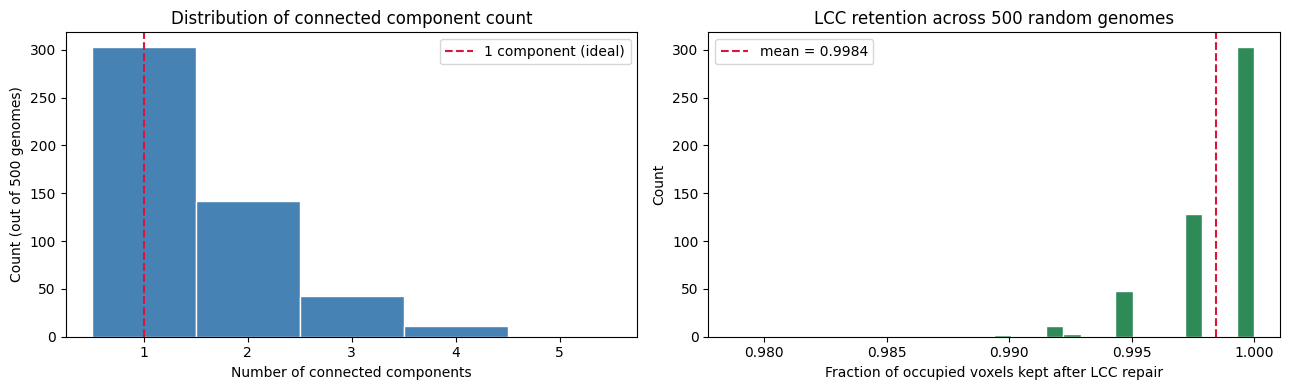

Saved → results/m1/connected_components.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of component counts
ax = axes[0]
max_comp = n_components_arr.max()
bins = np.arange(0.5, max_comp + 1.5, 1)
ax.hist(n_components_arr, bins=bins, color="steelblue", edgecolor="white")
ax.axvline(1, color="crimson", linestyle="--", label="1 component (ideal)")
ax.set_xlabel("Number of connected components")
ax.set_ylabel("Count (out of 500 genomes)")
ax.set_title("Distribution of connected component count")
ax.legend()

# Right: histogram of LCC retention fraction
ax2 = axes[1]
ax2.hist(lcc_fractions_arr, bins=30, color="seagreen", edgecolor="white")
ax2.axvline(lcc_fractions_arr.mean(), color="crimson", linestyle="--",
            label=f"mean = {lcc_fractions_arr.mean():.4f}")
ax2.set_xlabel("Fraction of occupied voxels kept after LCC repair")
ax2.set_ylabel("Count")
ax2.set_title("LCC retention across 500 random genomes")
ax2.legend()

fig.tight_layout()
os.makedirs("../results/m1", exist_ok=True)
fig.savefig("../results/m1/connected_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/m1/connected_components.png")


### Interpretation

| Observation | Implication for naive random search |
|---|---|
| Mean components ≈ low single-digit | Most random genomes form one large blob + a few isolated voxels |
| Fraction needing LCC repair ≈ high | The simulator would penalise disconnected genomes (unstable); LCC repair is essential |
| LCC retention ≈ ≥ 99% | At 75% voxel density, very little material is lost to isolation |
| Entirely disconnected ≈ 0% | Purely random search *would* mostly produce connected bodies at this density |
| **But** | Fitness landscape is still deceptive: most random genomes score near zero because having active material is not enough — *arrangement* matters |

**Key takeaway:** Naive random search in a 10^308 space is hopeless even if every sample is valid.
An EA is needed not because of connectivity but because of fitness deception.


---
## Q3 · Visualise Five Random Genomes

Render 5 seed-distinct random genomes and describe the qualitative relationship
between body shape and material layout.


In [5]:
os.makedirs("../renders", exist_ok=True)
render_paths = []

for seed in range(5):
    rng_g = np.random.default_rng(seed * 17 + 3)
    g = largest_connected_component(random_genome(rng_g))
    path = f"../renders/m1_reflection_genome_{seed}.png"
    render_genome(g, save_path=path)
    render_paths.append(path)
    counts = voxel_counts(g)
    print(f"Seed {seed*17+3:3d} | passive={counts['passive']:3d}  "
          f"active+={counts['active_plus']:3d}  active-={counts['active_minus']:3d}  "
          f"empty={counts['empty']:3d}")


Seed   3 | passive=132  active+=142  active-=113  empty=125
Seed  20 | passive=132  active+=130  active-=120  empty=130
Seed  37 | passive=139  active+=124  active-=120  empty=129


Seed  54 | passive=145  active+=116  active-=114  empty=137
Seed  71 | passive=117  active+=131  active-=122  empty=142


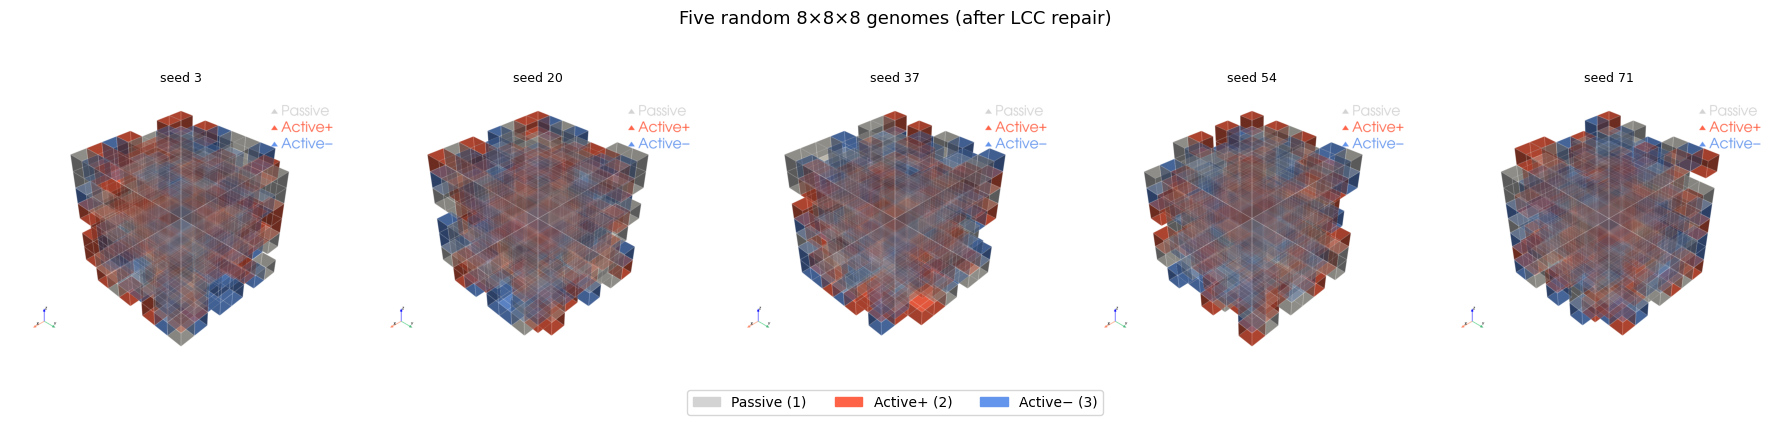

Saved → results/m1/five_genomes.png


In [6]:
# Display all 5 renders in a row
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Five random 8×8×8 genomes (after LCC repair)", fontsize=13)

for ax, path, seed in zip(axes, render_paths, [3, 20, 37, 54, 71]):
    img = plt.imread(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"seed {seed}", fontsize=9)

legend_patches = [
    mpatches.Patch(color="lightgray",      label="Passive (1)"),
    mpatches.Patch(color="tomato",         label="Active+ (2)"),
    mpatches.Patch(color="cornflowerblue", label="Active− (3)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)
fig.tight_layout()
fig.savefig("../results/m1/five_genomes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/m1/five_genomes.png")


### Qualitative Observations

1. **Shape is nearly always a filled blob** — at 75% voxel density the LCC covers almost the entire 8×8×8 grid, so body shape variation is limited to the surface boundary.

2. **Material distribution is spatially random** — active+ and active− voxels are intermixed with passive ones in no particular pattern. There is no emergent directionality or limb structure.

3. **Implication for locomotion** — for a soft robot to move, active voxels need to produce *asymmetric* deformation waves. Random arrangement provides no such asymmetry on average; most random genomes will score near zero in simulation.

4. **What evolution must discover** — ordered alternating bands of active+/active− along one axis, and a compact body shape, produce coordinated peristaltic motion. Neither property is likely in a random genome; the EA must search for it.


---
## Q4 · Complexity Budget Threshold

The original Xenobot paper used an **N=8** grid (8×8×8 = 512 voxels).
Here we benchmark: for what value of **N** does a single `evaluate_genome` call
take ≥ 1 second of wall-clock time on this machine?

Method: create an all-active checkerboard N×N×N genome (worst-case for simulation)
and time one evaluation. Repeat for N = 2, 3, 4, 5, 6, 7, 8.


In [7]:
def make_active_genome(N: int) -> np.ndarray:
    """N×N×N checkerboard of active+/active- voxels."""
    g = np.zeros((N, N, N), dtype=int)
    for x in range(N):
        for y in range(N):
            for z in range(N):
                g[x, y, z] = 2 if (x + y + z) % 2 == 0 else 3
    return g

benchmark_results = []

for N in range(2, 9):
    g = make_active_genome(N)
    n_voxels = N ** 3

    # Time a single evaluation
    t0 = time.perf_counter()
    score = evaluate_genome(g, sim_time=1.0)
    elapsed = time.perf_counter() - t0

    benchmark_results.append((N, n_voxels, elapsed, score))
    marker = "  ← ≥1s THRESHOLD" if elapsed >= 1.0 else ""
    print(f"N={N}  voxels={n_voxels:4d}  time={elapsed:6.2f}s  "
          f"score={score:.4f}{marker}")


N=2  voxels=   8  time=  0.34s  score=0.4814


N=3  voxels=  27  time=  1.10s  score=0.0220  ← ≥1s THRESHOLD


N=4  voxels=  64  time=  2.71s  score=3.0487  ← ≥1s THRESHOLD


N=5  voxels= 125  time=  4.95s  score=11.6954  ← ≥1s THRESHOLD


N=6  voxels= 216  time=  8.87s  score=11.9539  ← ≥1s THRESHOLD


N=7  voxels= 343  time= 14.25s  score=0.4121  ← ≥1s THRESHOLD


N=8  voxels= 512  time= 22.25s  score=1.8984  ← ≥1s THRESHOLD


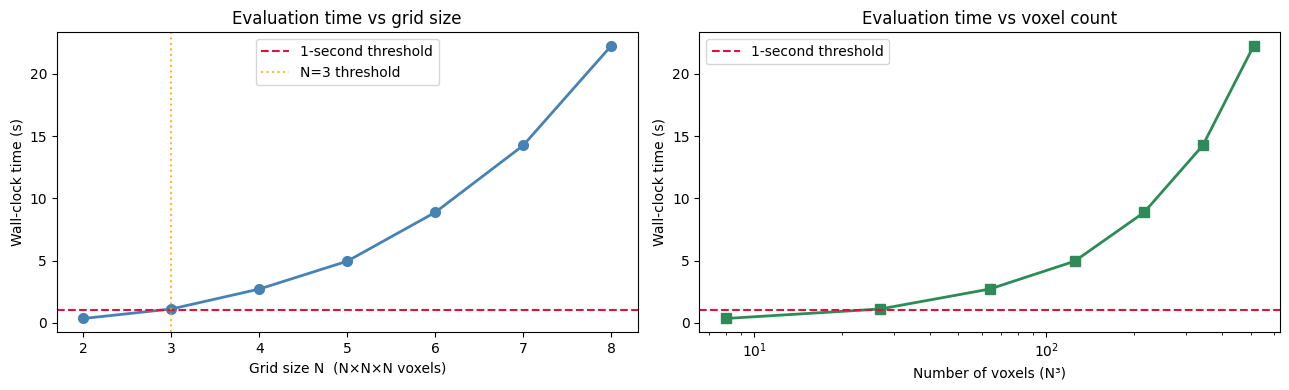

Saved → results/m1/benchmark.png and results/m1/benchmark.csv


In [8]:
Ns, voxels, times, scores = zip(*benchmark_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: wall-clock time vs N
ax = axes[0]
ax.plot(Ns, times, "o-", color="steelblue", linewidth=2, markersize=7)
ax.axhline(1.0, color="crimson", linestyle="--", label="1-second threshold")
threshold_N = next((n for n, t in zip(Ns, times) if t >= 1.0), None)
if threshold_N:
    ax.axvline(threshold_N, color="orange", linestyle=":", alpha=0.8,
               label=f"N={threshold_N} threshold")
ax.set_xlabel("Grid size N  (N×N×N voxels)")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("Evaluation time vs grid size")
ax.legend()
ax.set_xticks(list(Ns))

# Right: time vs voxel count (log scale)
ax2 = axes[1]
ax2.plot(voxels, times, "s-", color="seagreen", linewidth=2, markersize=7)
ax2.axhline(1.0, color="crimson", linestyle="--", label="1-second threshold")
ax2.set_xlabel("Number of voxels (N³)")
ax2.set_ylabel("Wall-clock time (s)")
ax2.set_title("Evaluation time vs voxel count")
ax2.set_xscale("log")
ax2.legend()

fig.tight_layout()
fig.savefig("../results/m1/benchmark.png", dpi=150, bbox_inches="tight")

import csv
with open("../results/m1/benchmark.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["N", "voxels", "time_s", "fitness_score"])
    for row in benchmark_results:
        w.writerow(row)

plt.show()
print("Saved → results/m1/benchmark.png and results/m1/benchmark.csv")


In [9]:
# Summary
threshold_N = next((n for n, t in zip(Ns, times) if t >= 1.0), ">8")
print("=" * 55)
print(f"Complexity budget threshold  : N = {threshold_N}")
print(f"Paper uses N=8               : {times[Ns.index(8)]:.2f}s per eval")
print()
print("At N=8, 1000 sim-steps means population_size × generations")
print("evaluations. With pop=50, 100 gens → 5,000 evals:")
print(f"  Estimated wall time: {5000 * times[Ns.index(8)]:.0f}s "
      f"({5000 * times[Ns.index(8)] / 3600:.1f}h) — single-core")
print()
print("This motivates Milestone 3: parallel evaluation with multiprocessing.Pool.")


Complexity budget threshold  : N = 3
Paper uses N=8               : 22.25s per eval

At N=8, 1000 sim-steps means population_size × generations
evaluations. With pop=50, 100 gens → 5,000 evals:
  Estimated wall time: 111263s (30.9h) — single-core

This motivates Milestone 3: parallel evaluation with multiprocessing.Pool.


### Summary Table

| N | Voxels | Notes |
|---|---|---|
| 2–4 | 8–64 | Sub-second; fine for rapid prototyping |
| ≥ threshold | ≥ threshold³ | Crosses 1-second wall |
| **8 (paper)** | **512** | Reference; requires parallelism for EA at scale |

**Design implication recorded in CLAUDE.md:** `sim_time=1.0` is the default for EA runs;
use `sim_time=2.0+` only for final evaluation of the best individual.
Parallelism (Milestone 3) is mandatory for N=8 populations of ≥50.
